![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 Extra E02 - ReAct Loop
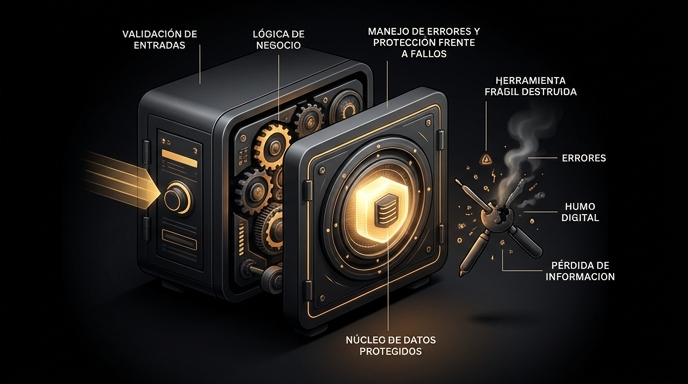

## Proposito

Este notebook muestra la solucion completa del esqueleto minimo de un agente ReAct.

La este notebook define ReAct como:

```text
Reasoning + Acting
```

Y lo representa como:

```text
Thought -> Action -> Observation -> Thought -> Action -> Observation -> Final Answer
```

En este ejercicio no usamos un LLM para decidir. Usamos reglas simples para que puedas ver claramente el mecanismo del agente.


## Definiciones clave

| Concepto | Definicion | En este notebook |
|---|---|---|
| State | Memoria de corto plazo del agente. | `state` guarda `customer` y `balance`. |
| Action | Tool que el agente decide ejecutar. | `get_customer`, `get_balance`, `finalize`. |
| Observation | Resultado devuelto por una tool. | Diccionarios con `success` y datos. |
| Trace | Historial auditable de pasos. | Lista con `step`, `action`, `observation`. |
| Stop condition | Regla para terminar. | `finalize` o `max_steps reached`. |
| max_steps | Limite de seguridad. | Evita loops infinitos. |

Idea central: un agente no deberia actuar sin limite. Debe saber cuando responder y cuando fallar de forma controlada.


## C?mo encaja este notebook en la diferencia Pipeline vs AI Agent

Un pipeline ejecutaria una secuencia fija de funciones. Este notebook muestra el patron de un **AI Agent** porque la proxima accion depende del **state**.

Las tools son simples y mockeadas, pero cumplen el mismo rol conceptual que una custom tool real:

- `get_customer`: obtiene un dato que faltaba;
- `get_balance`: obtiene otro dato necesario;
- `finalize`: construye la respuesta cuando el estado ya esta completo.

El grounding aca no viene de una API externa, sino de observaciones explicitas producidas por tools. Por eso el `trace` permite revisar como se llego a la respuesta.


## Solucion paso 1 - Tools disponibles

Las tools quedan igual. La diferencia esta en como el agente las selecciona y registra sus observaciones.


In [ ]:
TOOLS = {
    "get_customer": lambda state: {"success": True, "customer": "Acme"},
    "get_balance": lambda state: {"success": True, "balance": 1200},
    "finalize": lambda state: {
        "success": True,
        "answer": f"{state['customer']} owes USD {state['balance']}",
    },
}


## Solucion TODOs 1 a 3 - `choose_action()`

La policy mira que datos faltan en `state`.

Esto implementa razonamiento deterministico: no hay LLM, pero si hay decision basada en estado.


In [ ]:
def choose_action(state):
    if "customer" not in state:
        return "get_customer"
    if "balance" not in state:
        return "get_balance"
    return "finalize"


## Solucion TODO 4 - `run_agent()`

El loop completo implementa el patron ReAct:

```text
Thought: ¿qué falta en state?
Action: ejecutar tool elegida
Observation: guardar resultado
Update: actualizar state
Stop: finalizar o cortar por max_steps
```


In [ ]:
def run_agent(max_steps=5):
    state = {}
    trace = []

    for step in range(1, max_steps + 1):
        action = choose_action(state)
        observation = TOOLS[action](state)
        trace.append({"step": step, "action": action, "observation": observation})

        if not observation["success"]:
            return {"success": False, "error": f"tool failed: {action}", "trace": trace}

        state.update({k: v for k, v in observation.items() if k != "success"})

        if action == "finalize":
            return {"success": True, "answer": observation["answer"], "trace": trace}

    return {"success": False, "error": "max_steps reached", "trace": trace}


## Ejecutar Resolution

Los checks prueban el camino feliz y el caso de seguridad con `max_steps=1`.


In [ ]:
def run_checks():
    result = run_agent()
    assert result["success"] is True
    assert result["answer"] == "Acme owes USD 1200"
    assert [step["action"] for step in result["trace"]] == [
        "get_customer",
        "get_balance",
        "finalize",
    ]

    limited = run_agent(max_steps=1)
    assert limited["success"] is False
    assert "max_steps" in limited["error"]

    print("M3L1 E02 Resolution checks passed")


run_checks()


## Cierre

Este Resolution muestra que un agente productivo necesita:

- decision por estado;
- ejecucion de tools;
- observaciones registradas;
- actualizacion de estado;
- trace auditable;
- condicion de parada.

Sin esas piezas, solo tenemos un flujo de funciones, no un agente controlable.
